### Quellen für die Eigenschaften

Für diese Aminosäuren-Eigenschaften verwende ich meist standardisierte Tabellen aus der Literatur und Datenbanken:

#### Hydrophobizität (Kyte-Doolittle Skala)
Kyte, J., & Doolittle, R. F. (1982). A simple method for displaying the hydropathic character of a protein. Journal of Molecular Biology, 157(1), 105–132.
DOI: 10.1016/0022-2836(82)90515-0

#### Ladung (einfach: +1, -1, 0 je nach pH7)
(Standardannahme aus Biochemie-Lehrbüchern wie Nelson et al., Lehninger Principles of Biochemistry, 8th Edition)

#### Molekulargewicht (Durchschnittswert aus Uniprot, 2024, leicht gerundet)
(Basis: Monoisotopische Masse ohne Wasserstoff am N- und C-Terminus; Quelle: Uniprot)

#### Polarität (Grantham, 1974)
Grantham, R. (1974). Amino acid difference formula to help explain protein evolution. Science, 185(4154), 862–864.
DOI: 10.1126/science.185.4154.862

In [196]:
# Eigenschaften der AS in Dictionary anlegen


amino_acid_properties = {
    'A': {'hydrophobicity': 1.8, 'charge': 0, 'mass': 89.09, 'polarity': 8.1},
    'R': {'hydrophobicity': -4.5, 'charge': +1, 'mass': 174.20, 'polarity': 10.5},
    'N': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 132.12, 'polarity': 11.6},
    'D': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 133.10, 'polarity': 13.0},
    'C': {'hydrophobicity': 2.5, 'charge': 0, 'mass': 121.15, 'polarity': 5.5},
    'Q': {'hydrophobicity': -3.5, 'charge': 0, 'mass': 146.15, 'polarity': 10.5},
    'E': {'hydrophobicity': -3.5, 'charge': -1, 'mass': 147.13, 'polarity': 12.3},
    'G': {'hydrophobicity': -0.4, 'charge': 0, 'mass': 75.07, 'polarity': 9.0},
    'H': {'hydrophobicity': -3.2, 'charge': +1, 'mass': 155.16, 'polarity': 10.4},
    'I': {'hydrophobicity': 4.5, 'charge': 0, 'mass': 131.17, 'polarity': 5.2},
    'L': {'hydrophobicity': 3.8, 'charge': 0, 'mass': 131.17, 'polarity': 4.9},
    'K': {'hydrophobicity': -3.9, 'charge': +1, 'mass': 146.19, 'polarity': 11.3},
    'M': {'hydrophobicity': 1.9, 'charge': 0, 'mass': 149.21, 'polarity': 5.7},
    'F': {'hydrophobicity': 2.8, 'charge': 0, 'mass': 165.19, 'polarity': 5.2},
    'P': {'hydrophobicity': -1.6, 'charge': 0, 'mass': 115.13, 'polarity': 8.0},
    'S': {'hydrophobicity': -0.8, 'charge': 0, 'mass': 105.09, 'polarity': 9.2},
    'T': {'hydrophobicity': -0.7, 'charge': 0, 'mass': 119.12, 'polarity': 8.6},
    'W': {'hydrophobicity': -0.9, 'charge': 0, 'mass': 204.23, 'polarity': 5.4},
    'Y': {'hydrophobicity': -1.3, 'charge': 0, 'mass': 181.19, 'polarity': 6.2},
    'V': {'hydrophobicity': 4.2, 'charge': 0, 'mass': 117.15, 'polarity': 5.9}
}

In [197]:
import pandas as pd  # Damit können wir Tabellen verarbeiten

# Die Datei einlesen (TSV = tab-getrennte Werte)
df = pd.read_csv("sars_cov2_cdrh3.tsv", sep="\t")

# Vorher: Wie viele Zeilen und wie viele fehlen?
#len(df): Zählt, wie viele Zeilen dein DataFrame df hat
print("Vorher: Zeilen gesamt:", len(df))

print("Vorher: Fehlende in CDR_H3:", df["CDR_H3"].isna().sum())
#df["CDR_H3"]: Zugriff auf die Spalte CDR_H3 aus dem DataFrame df
#.isna(): Gibt für jede Zelle True, wenn kein Wert drin ist (z. B. NaN).
#.sum(): Zählt alle True-Werte (also alle leeren Zellen).


# Nur Zeilen behalten, wo CDR_H3 wirklich ein sinnvoller Text ist
df = df[df["CDR_H3"].apply(lambda x: isinstance(x, str) and x.strip().lower() not in ["", "nan", "none"])]
#df = ...= Wir überschreiben den alten df mit einem neuen, in dem nur noch gültige Zeilen enthalten sind.
#df[ ... ] = Filtern: Wir behalten nur die Zeilen, bei denen in den eckigen Klammern True steht.
#df["CDR_H3"] = Wir arbeiten mit der Spalte CDR_H3.
#.apply(...) = Wir wenden eine Funktion auf jeden Wert in dieser Spalte an.
#lambda x: ... = Eine kurze anonyme Funktion, die wir direkt in der apply-Zeile schreiben.
#x = ist hier jede einzelne Zelle in der Spalte CDR_H3.
# isinstance(x, str) = Prüft: Ist x ein String (also ein normaler Text)?
# x.strip()= Entfernt Leerzeichen am Anfang und Ende der Zelle.
#.lower() = Macht alles kleingeschrieben, z. B. "NaN" → "nan"(Das hilft, unabhängig von Groß-/Kleinschreibung zu filtern)
#not in ["", "nan", "none"] =Prüft: Ist der bereinigte Inhalt nicht in dieser Liste?
#"": Ein leerer Text
#"nan": Ein Text, der wie „nicht vorhanden“ aussieht
#"none": Auch ein möglicher leeres Platzhalter



# Nachher: Zeige, was übrig ist
print("Nachher: Zeilen übrig:", len(df))
#wie viele NaNs jetzt noch da sind
print("Nachher: Fehlende in CDR_H3:", df["CDR_H3"].isna().sum())

Vorher: Zeilen gesamt: 379
Vorher: Fehlende in CDR_H3: 1
Nachher: Zeilen übrig: 378
Nachher: Fehlende in CDR_H3: 0


### Tests die wir durchführen können:

1. Aminosäure-Häufigkeiten: Zählen, wie oft jede Aminosäure in jeder CDR H3 vorkommt.

2. Hydrophobizität, Ladung und Polarität: Mittlere Werte pro Sequenz.

3. Längenverteilung der CDR H3: Wie lang sind die Schleifen?

4. PCA: Dimensionen reduzieren und Cluster visualisieren.

5. Hierarchisches Clustering: Ähnliche Sequenzen gruppieren.

6. T-Test: Vergleiche zwischen Gruppen 

In [198]:
# 1.Aminosäure-Häufigkeiten: Zählen, wie oft jede Aminosäure in jeder CDR H3 vorkommt.


# keys (Buchstaben) aus Dictionary holen = Aminosäure-Liste erstellen
# amino_acid_properties ist dein Dictionary.
# .keys() holt alle Buchstaben ('A', 'R', 'N' usw.).
# list(...) macht daraus eine Liste
amino_acids = list(amino_acid_properties.keys()) 

# für jede Sequenz alle Aminosäuren zählen
# df.iterrows() geht jede Zeile durch.
# row["CDR_H3"] holt die Sequenz der aktuellen Zeile.
# index ist die Zeilennummer (0-basiert)
for index, row in df.iterrows():
    sequence = row["CDR_H3"]
    print(f"Sequenz {index+1}: {sequence}")

# AS zählen
    if isinstance(sequence, str):
        for aa in amino_acids:
            count = sequence.count(aa)
            print(f"  - {aa}: {count}")
            df.loc[index, f'count_{aa}'] = count
    else:
        print(f"Warnung: Zeile {index} hat keine gültige Sequenz. (Typ: {type(sequence)})")

        
        # Ausgabe: Zeige die ersten Zeilen mit den neuen Spalten
print(df.head())

Sequenz 1: TFGTYYDNTEDWFFDF
  - A: 0
  - R: 0
  - N: 1
  - D: 3
  - C: 0
  - Q: 0
  - E: 1
  - G: 1
  - H: 0
  - I: 0
  - L: 0
  - K: 0
  - M: 0
  - F: 4
  - P: 0
  - S: 0
  - T: 3
  - W: 1
  - Y: 2
  - V: 0
Sequenz 2: LPLGERIDY
  - A: 0
  - R: 1
  - N: 0
  - D: 1
  - C: 0
  - Q: 0
  - E: 1
  - G: 1
  - H: 0
  - I: 1
  - L: 2
  - K: 0
  - M: 0
  - F: 0
  - P: 1
  - S: 0
  - T: 0
  - W: 0
  - Y: 1
  - V: 0
Sequenz 3: HNGDPYDFWSGYNTWAGGLDV
  - A: 1
  - R: 0
  - N: 2
  - D: 3
  - C: 0
  - Q: 0
  - E: 0
  - G: 4
  - H: 1
  - I: 0
  - L: 1
  - K: 0
  - M: 0
  - F: 1
  - P: 1
  - S: 1
  - T: 1
  - W: 2
  - Y: 2
  - V: 1
Sequenz 4: QGDLGDWILLGY
  - A: 0
  - R: 0
  - N: 0
  - D: 2
  - C: 0
  - Q: 1
  - E: 0
  - G: 3
  - H: 0
  - I: 1
  - L: 3
  - K: 0
  - M: 0
  - F: 0
  - P: 0
  - S: 0
  - T: 0
  - W: 1
  - Y: 1
  - V: 0
Sequenz 5: QGDLGDWILLGY
  - A: 0
  - R: 0
  - N: 0
  - D: 2
  - C: 0
  - Q: 1
  - E: 0
  - G: 3
  - H: 0
  - I: 1
  - L: 3
  - K: 0
  - M: 0
  - F: 0
  - P: 0
  - S: 0
  - T:

In [199]:
# Schleife, um jede Sequenz durchzugehen. Für jede Aminosäure holen wir uns aus deinem Dictionary die Eigenschaft und bilden dann den Mittelwert
# = Berechne mittlere Hydrophobizität, Ladung und Polarität pro Sequenz

for index, row in df.iterrows():
    sequence = row["CDR_H3"]

    if isinstance(sequence, str):
        # Listen für die Werte
        hydrophobicities = []
        charges = []
        polarities = []
        masses = []

        # Gehe jede Aminosäure durch
        for aa in sequence:
            if aa in amino_acid_properties:
                hydrophobicities.append(amino_acid_properties[aa]['hydrophobicity'])
                charges.append(amino_acid_properties[aa]['charge'])
                polarities.append(amino_acid_properties[aa]['polarity'])
                masses.append(amino_acid_properties[aa]['mass'])
            else:
                print(f"Warnung: Unbekannte Aminosäure '{aa}' in Sequenz {index+1}")

        # Berechne die Mittelwerte (nur falls Listen nicht leer)
        if hydrophobicities:
            mean_hydrophobicity = sum(hydrophobicities) / len(hydrophobicities)
            df.loc[index, 'mean_hydrophobicity'] = mean_hydrophobicity

        if charges:
            mean_charge = sum(charges) / len(charges)
            df.loc[index, 'mean_charge'] = mean_charge

        if polarities:
            mean_polarity = sum(polarities) / len(polarities)
            df.loc[index, 'mean_polarity'] = mean_polarity

        if masses:
            mean_mass = sum(masses) / len(masses)
            df.loc[index, 'mean_mass'] = mean_mass

    else:
        print(f"⚠️ Warnung: Zeile {index+1} enthält keine gültige Sequenz (Typ: {type(sequence)})")
print(df.head())


# Erklärungen 
#for index, row in df.iterrows(): = Wir gehen jede Zeile (jede Sequenz) durch.

# sequence = row["CDR_H3"] = Hol dir die aktuelle Sequenz.

# hydrophobicities, charges, polarities = [] = Leere Listen zum Sammeln der Werte pro Aminosäure.

# for aa in sequence: = Gehe jede Aminosäure durch.

# amino_acid_properties[aa]['hydrophobicity'] = Hol den Hydrophobizitätswert der Aminosäure.

# sum(hydrophobicities) / len(hydrophobicities) = Berechne den Mittelwert.

# df.loc[index, 'mean_hydrophobicity'] = ... = Speichere den Wert direkt im DataFrame

    pdb heavy_chain                 CDR_H3  count_A  count_R  count_N  \
0  9cci           B       TFGTYYDNTEDWFFDF      0.0      0.0      1.0   
1  9ccj           H              LPLGERIDY      0.0      1.0      0.0   
2  9bj2           H  HNGDPYDFWSGYNTWAGGLDV      1.0      0.0      2.0   
3  8z6r           E           QGDLGDWILLGY      0.0      0.0      0.0   
4  8z6s           E           QGDLGDWILLGY      0.0      0.0      0.0   

   count_D  count_C  count_Q  count_E  count_G  count_H  count_I  count_L  \
0      3.0      0.0      0.0      1.0      1.0      0.0      0.0      0.0   
1      1.0      0.0      0.0      1.0      1.0      0.0      1.0      2.0   
2      3.0      0.0      0.0      0.0      4.0      1.0      0.0      1.0   
3      2.0      0.0      1.0      0.0      3.0      0.0      1.0      3.0   
4      2.0      0.0      1.0      0.0      3.0      0.0      1.0      3.0   

   count_K  count_M  count_F  count_P  count_S  count_T  count_W  count_Y  \
0      0.0      0.0  

In [200]:
# 3. Längenverteilung der CDR H3: Wie lang sind die Schleifen?

# Gehe jede Zeile durch
for index, row in df.iterrows():
    sequence = row["CDR_H3"]
    
    # Berechne die Länge der Sequenz
    length = len(sequence)
    
    # Speichere die Länge im DataFrame (nur lokal)
    df.loc[index, 'cdr_h3_length'] = length

    # Ausgabe zur Kontrolle
    print(f"Sequenz {index+1}: Länge = {length}")

    # um Daten in CSV-Datei zu speichern
    df.to_csv("cdr_h3_with_all_features.csv", index=False)

#df.to_csv(...) = exportiert dein DataFrame in eine CSV-Datei.
# "cdr_h3_with_all_features.csv" = der Dateiname
# index=False = Zeilennummern werden nicht als zusätzliche Spalte in die CSV-Datei geschrieben

Sequenz 1: Länge = 16
Sequenz 2: Länge = 9
Sequenz 3: Länge = 21
Sequenz 4: Länge = 12
Sequenz 5: Länge = 12
Sequenz 6: Länge = 12
Sequenz 7: Länge = 12
Sequenz 8: Länge = 18
Sequenz 9: Länge = 13
Sequenz 10: Länge = 14
Sequenz 11: Länge = 18
Sequenz 12: Länge = 14
Sequenz 13: Länge = 18
Sequenz 14: Länge = 13
Sequenz 15: Länge = 14
Sequenz 16: Länge = 14
Sequenz 17: Länge = 14
Sequenz 18: Länge = 12
Sequenz 19: Länge = 18
Sequenz 20: Länge = 16
Sequenz 21: Länge = 8
Sequenz 22: Länge = 14
Sequenz 23: Länge = 17
Sequenz 24: Länge = 17
Sequenz 25: Länge = 13
Sequenz 26: Länge = 18
Sequenz 27: Länge = 9
Sequenz 28: Länge = 9
Sequenz 29: Länge = 9
Sequenz 30: Länge = 17
Sequenz 31: Länge = 11
Sequenz 32: Länge = 8
Sequenz 33: Länge = 9
Sequenz 34: Länge = 7
Sequenz 35: Länge = 9
Sequenz 36: Länge = 16
Sequenz 37: Länge = 16
Sequenz 38: Länge = 13
Sequenz 39: Länge = 14
Sequenz 40: Länge = 18
Sequenz 41: Länge = 13
Sequenz 42: Länge = 19
Sequenz 43: Länge = 19
Sequenz 44: Länge = 13
Sequen

In [201]:
#kurz Tabelle anzeigen für überblick
pd.set_option('display.max_columns', None)  # zeigt alle Spalten
df.head(3)


,pdb,heavy_chain,CDR_H3,count_A,count_R,count_N,count_D,count_C,count_Q,count_E,count_G,count_H,count_I,count_L,count_K,count_M,count_F,count_P,count_S,count_T,count_W,count_Y,count_V,mean_hydrophobicity,mean_charge,mean_polarity,mean_mass,cdr_h3_length
0,9cci,B,TFGTYYDNTEDWFFDF,0.0,0.0,1.0,3.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,3.0,1.0,2.0,0.0,-0.768750,-0.250000,8.518750,146.146875,16.0
1,9ccj,H,LPLGERIDY,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.300000,-0.111111,8.222222,135.481111,9.0
2,9bj2,H,HNGDPYDFWSGYNTWAGGLDV,1.0,0.0,2.0,3.0,0.0,0.0,0.0,4.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,-0.819048,-0.095238,8.652381,130.083810,21.0


Features: ['count_A', 'count_R', 'count_N', 'count_D', 'count_C', 'count_Q', 'count_E', 'count_G', 'count_H', 'count_I', 'count_L', 'count_K', 'count_M', 'count_F', 'count_P', 'count_S', 'count_T', 'count_W', 'count_Y', 'count_V', 'mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass', 'cdr_h3_length']
PCA1-Gewichte: [ 0.03618069 -0.29349919 -0.22737511 -0.04240246 -0.1369478  -0.12544121
  0.04927614 -0.00694187 -0.19176395  0.03634838  0.1324246  -0.07503586
  0.19593103 -0.24084415 -0.19751185 -0.24036935 -0.07493604 -0.15837902
 -0.25326885  0.2103362   0.35697641 -0.31901958 -0.08764023 -0.279331
 -0.33710937]
PCA2-Gewichte: [ 0.29582216  0.12466704  0.13776409 -0.20292636  0.17913737 -0.05595051
 -0.03554632  0.14675316 -0.00904693  0.26716022  0.1404553  -0.0091433
  0.04153454  0.07961646  0.18188876  0.07400244  0.2073043   0.13973777
 -0.20896559  0.21821021  0.37776792  0.29629305 -0.30051829 -0.27461004
  0.30145151]


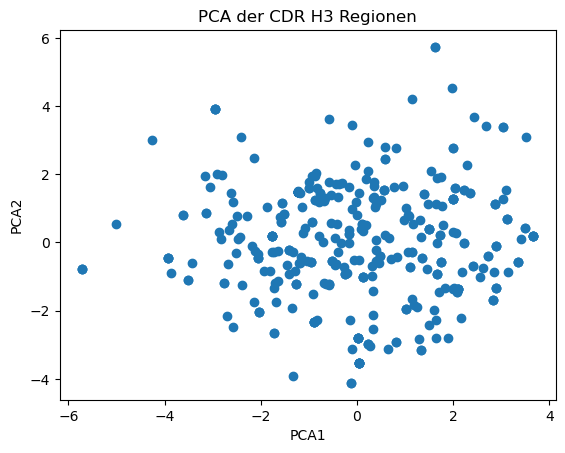

In [202]:
# 4. PCA: Dimensionen reduzieren und Cluster visualisieren

# Pakete importieren
# StandardScaler: Damit alle Features denselben Einfluss auf die PCA haben — sonst würden große Zahlen (z. B. Masse) die Analyse dominieren.
# PCA: Damit wir die Daten auf wenige Dimensionen reduzieren und Muster/Cluster erkennen können.
# matplotlib.pyplot: Damit wir die Ergebnisse schön als Plot darstellen können
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features auswählen (Erstellen eine Liste mit allen Spaltennamen in df, beginnt mit dem Text 'count_')
# pca_features = ... anlegen neuer Variable namens pca_features (Darin abspeichern einer Liste mit Namen der Spalten, die wir für PCA verwenden)
# df.columns = Liste mit allen Spaltennamen des df
# if col.startswith('count_') = Prüfe, ob Spaltenname mit „count_“ anfängt
# [ ... ] = Spaltennamen, die Bedingung erfüllen, werden in Liste gepackt
# pca_features += ...= Kurzschreibweise um „Liste zu erweitern“ 
# +=  = bedeutet Liste pca_features wird um die Werte rechts von += ergänzt
pca_features = [col for col in df.columns if col.startswith('count_')]
pca_features += ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass', 'cdr_h3_length']

# Features skalieren
# scaler = selbstgewählter Variablenname; verwendet, um Skalierungsobjekt zu speichern.
# =: Zuweisungsoperator
# StandardScaler():  Aufruf der Klasse StandardScaler aus scikit-learn.
# StandardScaler = Klasse, die Daten transformiert: jede Spalte einen Mittelwert von 0 hat (zentriert) und eine Standardabweichung von 1 (normiert) hat.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[pca_features])

# PCA berechnen
# PCA(...): Aufruf der PCA-Klasse aus scikit-learn, die die Hauptkomponentenanalyse durchführt
#n_components: Parameter von PCA, der sagt:„Wie viele Hauptkomponenten möchtest du berechnen?“
# 2: Daten auf 2 Dimensionen reduzieren
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)


# Ergebnisse speichern
# df['PCA1'] = ...= Neue Spalte 'PCA1' im df, mit allen Werten aus PCA-Komponente
# pca_result[:, 0]=	Alle Zeilen, erste Spalte (PCA1) aus dem PCA-Ergebnis
# df['PCA2'] = ...	= Neue Spalte 'PCA2' im df , mit allen Werten aus der zweiten PCA-Komponente
#pca_result[:, 1]= Alle Zeilen, zweite Spalte (PCA2) aus dem PCA-Ergebnis
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]


# Features und Gewichte ausgeben
# print("Features:", pca_features)= Zeigt Namen der Features, die für die PCA verwendet wurden.
# pca.components_	= 2D-Array mit den Gewichten aller Features für jede Hauptkomponente.
# pca.components_[0]	Erste Zeile: Gewichte für PCA1.
# pca.components_[1]	Zweite Zeile: Gewichte für PCA2.
# print(...) =Gibt Infos in Konsole aus, damit du sehen kannst, welche Features wie stark wirken
print("Features:", pca_features)
print("PCA1-Gewichte:", pca.components_[0])
print("PCA2-Gewichte:", pca.components_[1])

# Scatter-Plot
#plt.scatter(...) = Erstellt einen Streudiagramm (Punktplot) mit PCA1 auf der X-Achse und PCA2 auf der Y-Achse.
# plt.xlabel(...)	= Beschriftet die X-Achse mit „PCA1“.
# plt.ylabel(...)	= Beschriftet die Y-Achse mit „PCA2“.
# plt.title(...) =	Gibt dem Plot einen Titel, damit du weißt, was er zeigt.
# plt.show()	= Zeigt den Plot auf dem Bildschirm an
plt.scatter(df['PCA1'], df['PCA2'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA der CDR H3 Regionen')
plt.show()

Was sagt mir die Analyse jetzt?

👉 Mit dem Scatter-Plot kannst du:

- Cluster oder Gruppen erkennen:
Wenn Punkte eng beieinanderliegen, sind sich diese Sequenzen im Muster ihrer Features (Counts, Mittelwerte etc.) ähnlich.

- Ausreißer erkennen:
Punkte, die weit abseits liegen, zeigen Sequenzen, die sehr speziell sind (z. B. viele oder wenige bestimmte Aminosäuren).

- Ähnliche Sequenzen vergleichen:
Wenn bestimmte Sequenzen ähnliche PCA-Werte haben, dann haben sie ähnliche Eigenschaften (Counts, Mittelwerte etc.)

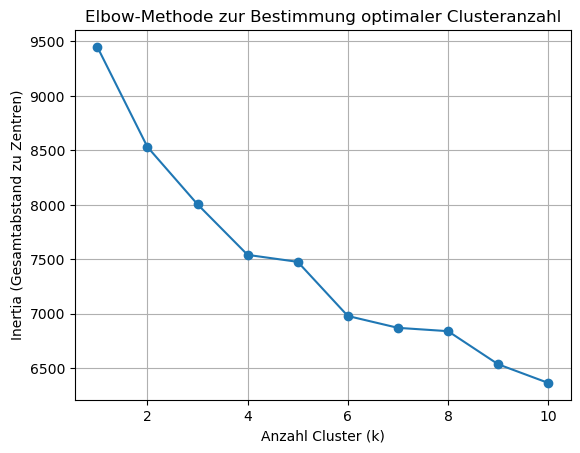

In [203]:
# Nur Spalten, die für Clustering sinnvoll sind:
pca_features = [col for col in df.columns if col.startswith("count_")]
pca_features += ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass', 'cdr_h3_length']

# Standardisieren
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[pca_features])

#Optimale Clusteranzahl bestimmen (Elbow-Methode
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

# Teste Clusteranzahl von 1 bis 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # inertia = wie weit die Punkte vom Clusterzentrum entfernt sind

# Plot
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Anzahl Cluster (k)')
plt.ylabel('Inertia (Gesamtabstand zu Zentren)')
plt.title('Elbow-Methode zur Bestimmung optimaler Clusteranzahl')
plt.grid()
plt.show()


Was zeigt dieser Elbow-Plot?

- Die Y-Achse zeigt die Inertia (= wie weit die Punkte durchschnittlich von ihrem Clusterzentrum entfernt sind).

- Die X-Achse zeigt die Anzahl der Cluster (k), die du ausprobiert hast.

Ziel der Analyse:

Man sucht die Stelle, wo sich der Fehler (Inertia) nicht mehr stark verbessert – also wo die Kurve abflacht.
Das nennt man den „Elbow-Punkt“ 


Was sehen wir bei uns?

- Von k=1 bis k=4 sinkt die Inertia deutlich.

- Ab k=4 → k=5 und höher ist die Verbesserung nur noch klein.

Fazit:
- Der Ellbogen ist bei k = 4.

-> 4 Cluster sind eine sinnvolle Wahl 

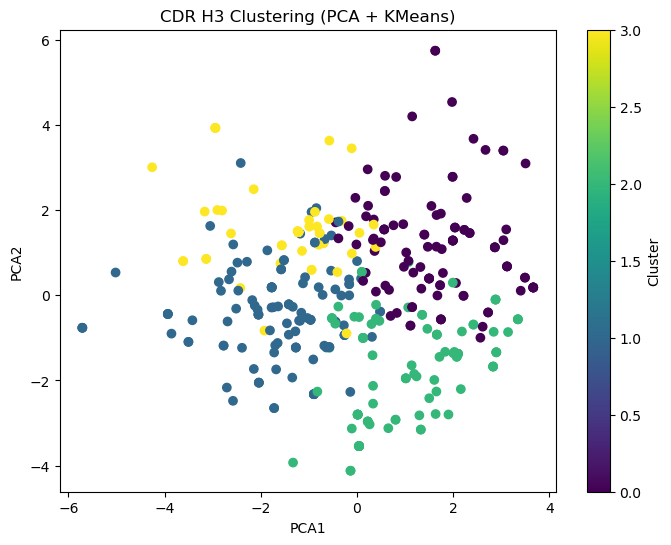

In [204]:
#KMeans mit optimaler Clusteranzahl durchführen
kmeans = KMeans(n_clusters=4, random_state=0)
df['Cluster'] = kmeans.fit_predict(X_scaled)


#Die Cluster sichtbar machen (PCA für 2D-Projektion)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)

df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('CDR H3 Clustering (PCA + KMeans)')
plt.colorbar(label='Cluster')
plt.show()



In [205]:
#Zähle, wie viele Sequenzen in jedem Cluster sind
print("Sequenzen pro Cluster:")
print(cluster_counts)

Sequenzen pro Cluster:
Cluster
0     76
1     84
2    126
3     92
Name: count, dtype: int64


In [206]:
from scipy.stats import f_oneway

# Gruppiere die Länge nach Cluster
gruppe_0 = df[df['Cluster'] == 0]['cdr_h3_length']
gruppe_1 = df[df['Cluster'] == 1]['cdr_h3_length']
gruppe_2 = df[df['Cluster'] == 2]['cdr_h3_length']
gruppe_3 = df[df['Cluster'] == 3]['cdr_h3_length']

# ANOVA-Test
f_stat, p_value = f_oneway(gruppe_0, gruppe_1, gruppe_2, gruppe_3)

print("F-Statistik:", f_stat)
print("p-Wert:", p_value)


F-Statistik: 85.73568434499899
p-Wert: 3.0961759342415897e-42


= Ja, es gibt einen hochsignifikanten Unterschied in der Länge der CDR H3 Sequenz zwischen den Clustern

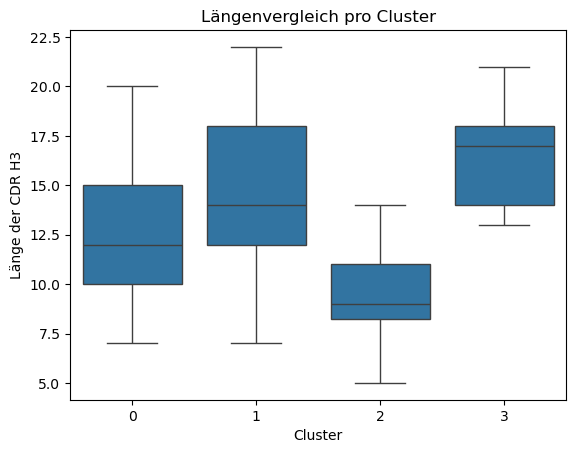

In [207]:
#Wie lang sind die Sequenzen in jedem Cluster?
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Cluster', y='cdr_h3_length', data=df)
plt.title("Längenvergleich pro Cluster")
plt.xlabel("Cluster")
plt.ylabel("Länge der CDR H3")
plt.show()


In [208]:
# Durchschnittliche Länge je Cluster
print(df.groupby("Cluster")["cdr_h3_length"].mean())


Cluster
0    12.692308
1    14.591667
2     9.622449
3    16.767857
Name: cdr_h3_length, dtype: float64


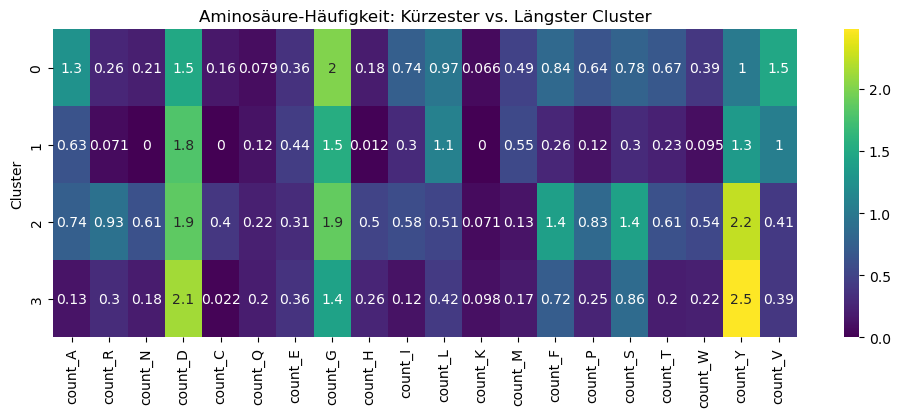

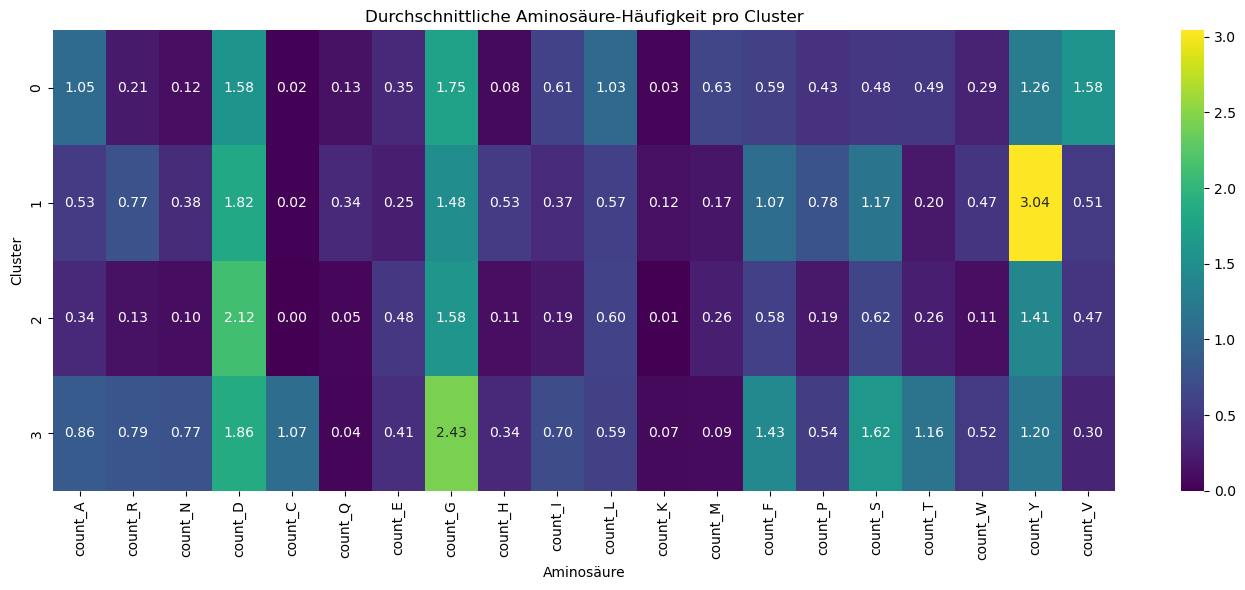

In [209]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
sns.heatmap(vergleich, annot=True, cmap="viridis")
plt.title("Aminosäure-Häufigkeit: Kürzester vs. Längster Cluster")
plt.show()



# Spalten mit Aminosäurezählungen auswählen
aa_columns = [col for col in df.columns if col.startswith("count_")]

# Gruppieren nach Cluster und Mittelwerte der Aminosäuren berechnen
vergleich = df.groupby("Cluster")[aa_columns].mean()

# Heatmap anzeigen
plt.figure(figsize=(14, 6))  # breiteres Format für bessere Lesbarkeit
sns.heatmap(vergleich, annot=True, cmap="viridis", fmt=".2f")
plt.title("Durchschnittliche Aminosäure-Häufigkeit pro Cluster")
plt.xlabel("Aminosäure")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()




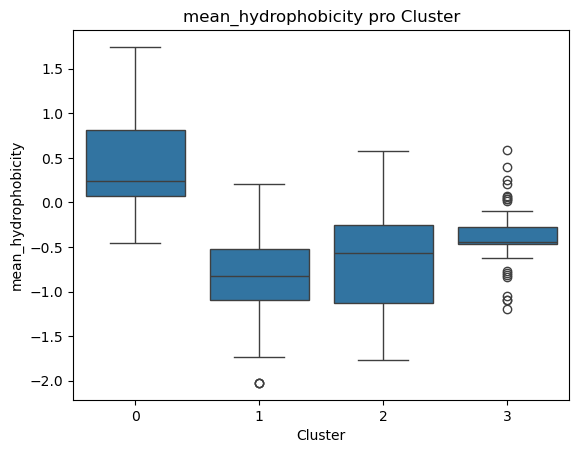

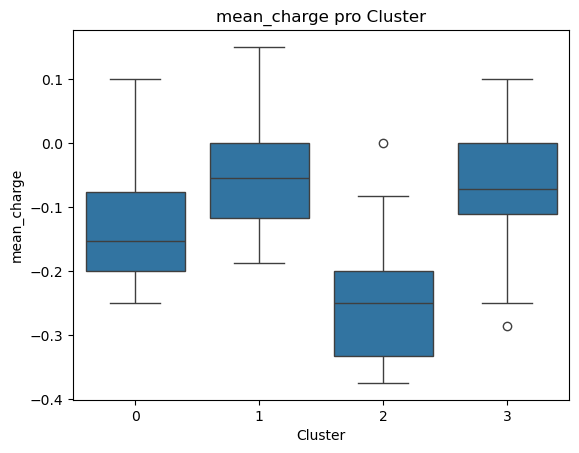

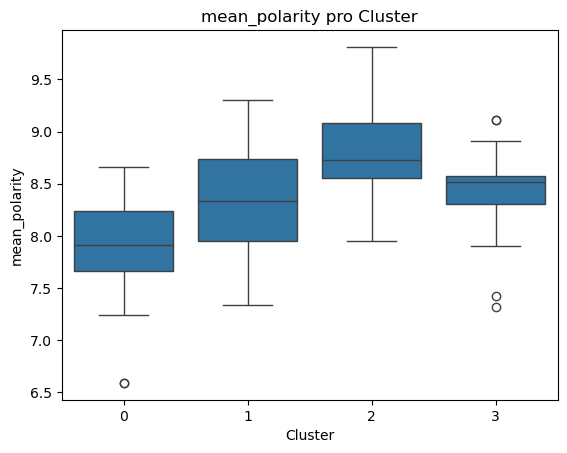

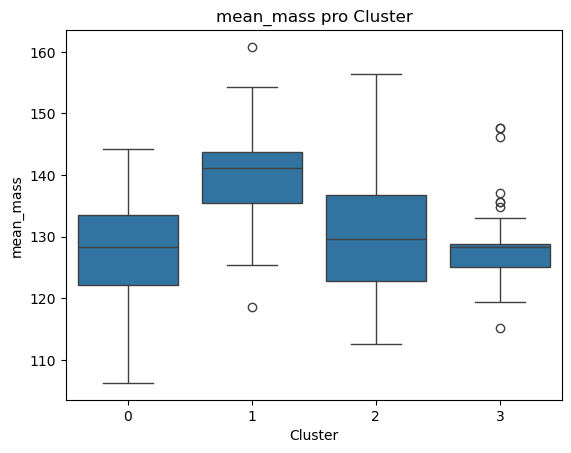

In [210]:
#Gibt es Unterschiede bei Hydrophobizität, Ladung usw.?
eigenschaften = ['mean_hydrophobicity', 'mean_charge', 'mean_polarity', 'mean_mass']

for feature in eigenschaften:
    sns.boxplot(x='Cluster', y=feature, data=df)
    plt.title(f"{feature} pro Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(feature)
    plt.show()


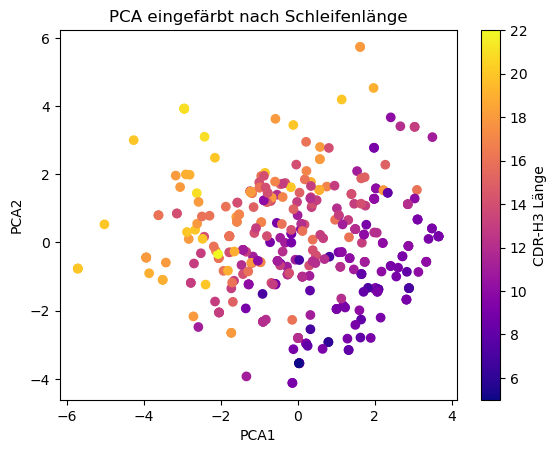

In [211]:
# Färben nach Länge
#Du kannst die Punkte nach Schleifenlänge einfärben, um zu sehen, ob bestimmte Längen in bestimmte Richtungen driften
plt.scatter(df['PCA1'], df['PCA2'], c=df['cdr_h3_length'], cmap='plasma')
plt.colorbar(label='CDR-H3 Länge')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA eingefärbt nach Schleifenlänge')
plt.show()


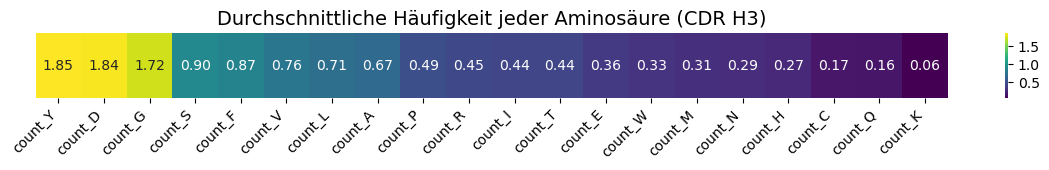

In [212]:
#Heatmap der Aminosäure-Häufigkeiten
import matplotlib.pyplot as plt
import seaborn as sns

# Aminosäurezählungen auswählen
aa_counts = df[[col for col in df.columns if col.startswith('count_')]]

# Mittelwerte berechnen
mean_counts = aa_counts.mean().sort_values(ascending=False)

# Neue, saubere Darstellung
plt.figure(figsize=(12, 1.8))  # Breiter und niedriger
sns.heatmap(
    mean_counts.to_frame().T,         # Nur eine Zeile, transponiert
    cmap='viridis',                   # Farben: schöner Kontrast
    annot=True,                       # Zahlen anzeigen
    fmt=".2f",                        # Zwei Nachkommastellen
    cbar_kws={"orientation": "vertical"}  # Farbleiste
)

plt.title('Durchschnittliche Häufigkeit jeder Aminosäure (CDR H3)', fontsize=14)
plt.yticks([])  # Y-Achse ausblenden (nur eine Zeile)
plt.xticks(rotation=45, ha='right')  # X-Achsenbeschriftung lesbar drehen
plt.tight_layout()
plt.show()



🔬 Interpretation biologisch:

Y (Tyrosin) ist häufig in CDR-H3. Das ist typisch, weil es:
- aromatisch ist,
- gut an verschiedene Antigene binden kann (z. B. über π-π-Interaktionen),
- oft in Kontaktflächen bei Antikörpern vorkommt.

D (Aspartat) ist negativ geladen → eventuell wichtig für elektrostatische Interaktion mit Virusproteinen.

G (Glycin) ist klein und flexibel → gut für Schleifenbeweglichkeit in der CDR-H3

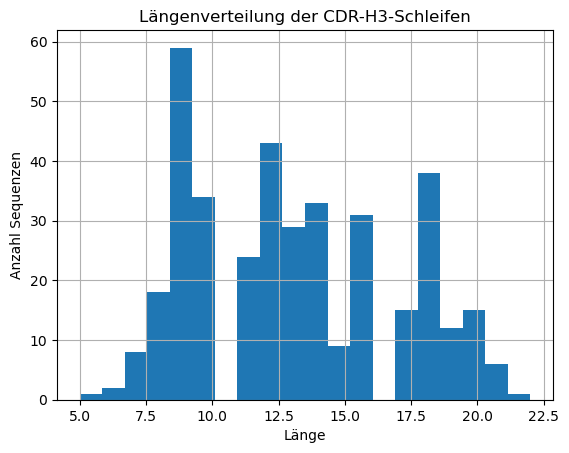

In [213]:
#Verteilung der Schleifenlänge analysieren
df['cdr_h3_length'].hist(bins=20)
plt.title('Längenverteilung der CDR-H3-Schleifen')
plt.xlabel('Länge')
plt.ylabel('Anzahl Sequenzen')
plt.show()


In [ ]:
# 5. Hierarchisches Clustering anhand der PCA : Ähnliche Sequenzen gruppieren



In [ ]:
# 6. T-Test: Vergleiche zwischen Gruppen 